In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported


In [5]:
import os

print("Checking files...")

folder_path = '/content/drive/MyDrive/Final Assignment/'

if os.path.exists(folder_path):
    print("Folder found")
    for item in os.listdir(folder_path):
        print("  ", item)
    telecom_path = folder_path + 'telecom/'
    if os.path.exists(telecom_path):
        print("Telecom folder found")
        for item in os.listdir(telecom_path):
            print("  ", item)
    else:
        print("Telecom folder not found")
else:
    print("Folder not found")

Checking files...
Folder found
   ENG_Company _A_ Dataset Overview.docx
   README.docx
   telecom
   Nathenael.ipynb
Telecom folder found
   Record.csv
   Client.csv


In [6]:
DATA_PATH = '/content/drive/MyDrive/Final Assignment/telecom/'

client_df = pd.read_csv(DATA_PATH + 'Client.csv')
record_df = pd.read_csv(DATA_PATH + 'Record.csv')
df = pd.merge(record_df, client_df, on='Customer_ID', how='inner')

print("Data loaded:", df.shape)

# clean missing values
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# create new features
df_clean['usage_per_month'] = df_clean['totmou'] / (df_clean['months'] + 1)
df_clean['revenue_per_month'] = df_clean['totrev'] / (df_clean['months'] + 1)
df_clean['drop_rate'] = (df_clean['drop_vce_Mean'] + df_clean['drop_dat_Mean']) / (df_clean['attempt_Mean'] + 1)

print("Data cleaned")

Data loaded: (100000, 100)
Data cleaned


In [7]:
churn_counts = df_clean['churn'].value_counts()
churn_rate = churn_counts[1] / len(df_clean) * 100

print("Churn Rate:", round(churn_rate, 2), "%")
print("Retained:", churn_counts[0], "(", round(churn_counts[0]/len(df_clean)*100, 1), "%)")
print("Churned:", churn_counts[1], "(", round(churn_rate, 1), "%)")

Churn Rate: 49.56 %
Retained: 50438 ( 50.4 %)
Churned: 49562 ( 49.6 %)


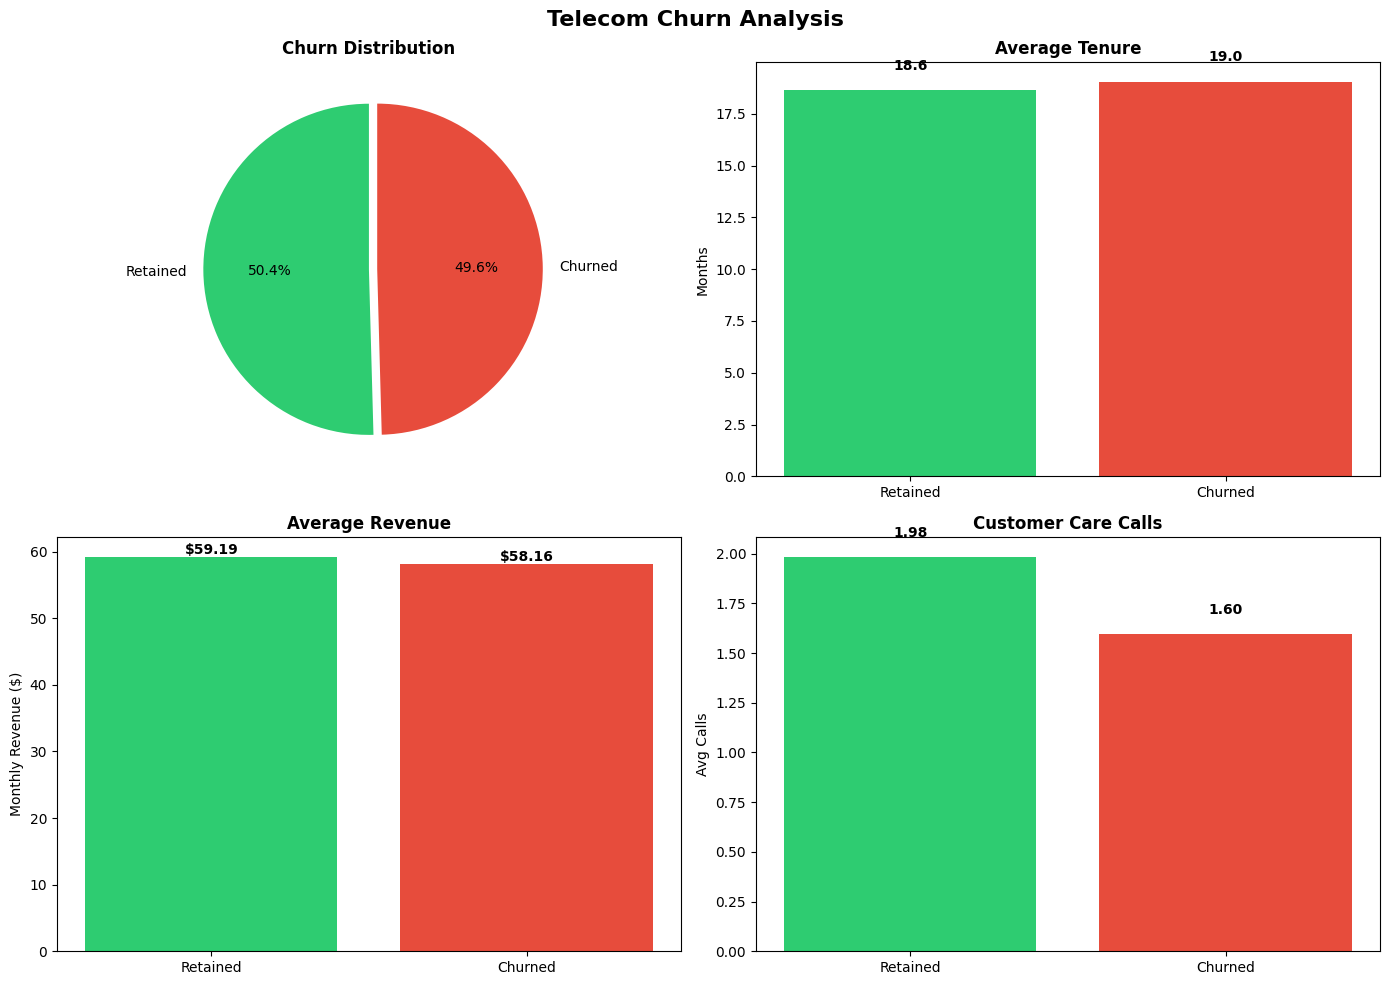

Visualizations saved


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telecom Churn Analysis', fontsize=16, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']

# churn pie chart
axes[0,0].pie(churn_counts.values, labels=['Retained', 'Churned'],
              autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
axes[0,0].set_title('Churn Distribution', fontsize=12, fontweight='bold')

# tenure comparison
months_by_churn = df_clean.groupby('churn')['months'].mean()
axes[0,1].bar(['Retained', 'Churned'], months_by_churn.values, color=colors)
axes[0,1].set_title('Average Tenure', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Months')
for i, v in enumerate(months_by_churn.values):
    axes[0,1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# revenue comparison
avg_rev = df_clean.groupby('churn')['rev_Mean'].mean()
axes[1,0].bar(['Retained', 'Churned'], avg_rev.values, color=colors)
axes[1,0].set_title('Average Revenue', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Monthly Revenue ($)')
for i, v in enumerate(avg_rev.values):
    axes[1,0].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

# customer care comparison
avg_care = df_clean.groupby('churn')['custcare_Mean'].mean()
axes[1,1].bar(['Retained', 'Churned'], avg_care.values, color=colors)
axes[1,1].set_title('Customer Care Calls', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Avg Calls')
for i, v in enumerate(avg_care.values):
    axes[1,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=200, bbox_inches='tight')
plt.show()
print("Visualizations saved")

In [9]:
target = 'churn'
features = df_clean.select_dtypes(include=['float64', 'int64']).columns
features = [col for col in features if col != target]

X = df_clean[features]
y = df_clean[target]

# remove constant columns
X = X.loc[:, X.nunique() > 1]
X = X.fillna(X.median())

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data ready:", X.shape[1], "features,", X.shape[0], "samples")

Data ready: 81 features, 100000 samples


In [10]:
def evaluate_model(y_test, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }

results = []

# logistic regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression'))

# random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest'))

# gradient boosting
gb = GradientBoostingClassifier(n_estimators=80, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_pred_gb, y_proba_gb, 'Gradient Boosting'))

results_df = pd.DataFrame(results)
print("Model Performance:")
print(results_df.to_string(index=False))

Model Performance:
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression   0.58335   0.581924 0.565779  0.573738 0.617664
      Random Forest   0.61650   0.613969 0.609262  0.611606 0.665423
  Gradient Boosting   0.61555   0.605385 0.644169  0.624175 0.669505


Best Model: Random Forest
  AUC-ROC: 0.6654
  Accuracy: 0.6165

Top 10 Features:
          Feature  Importance
          eqpdays    0.035954
       change_mou    0.027361
      Customer_ID    0.024987
           months    0.024495
       change_rev    0.021754
         mou_Mean    0.021439
           totrev    0.020239
           adjrev    0.020038
           avgqty    0.019863
revenue_per_month    0.019734


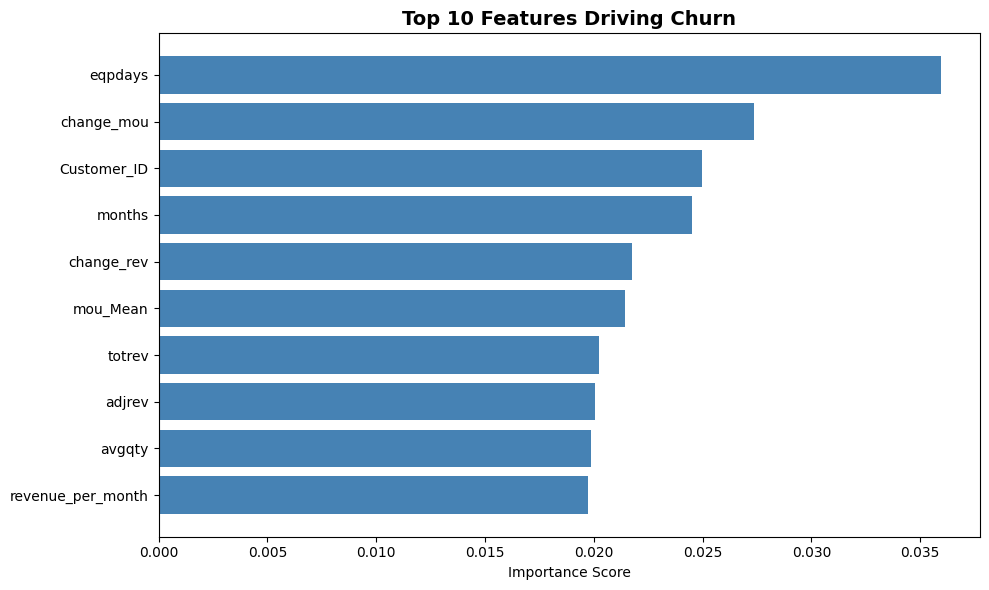

In [11]:
best_model = rf
y_pred_best = y_pred_rf
y_proba_best = y_proba_rf
best_metrics = results_df.iloc[1].to_dict()

print("Best Model: Random Forest")
print("  AUC-ROC:", round(best_metrics['AUC-ROC'], 4))
print("  Accuracy:", round(best_metrics['Accuracy'], 4))

# feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

# plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Features Driving Churn', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('churn_features.png', dpi=200, bbox_inches='tight')
plt.show()

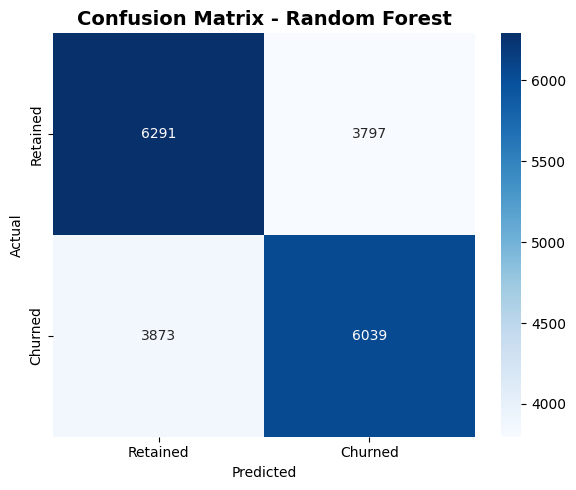

In [12]:
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('churn_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

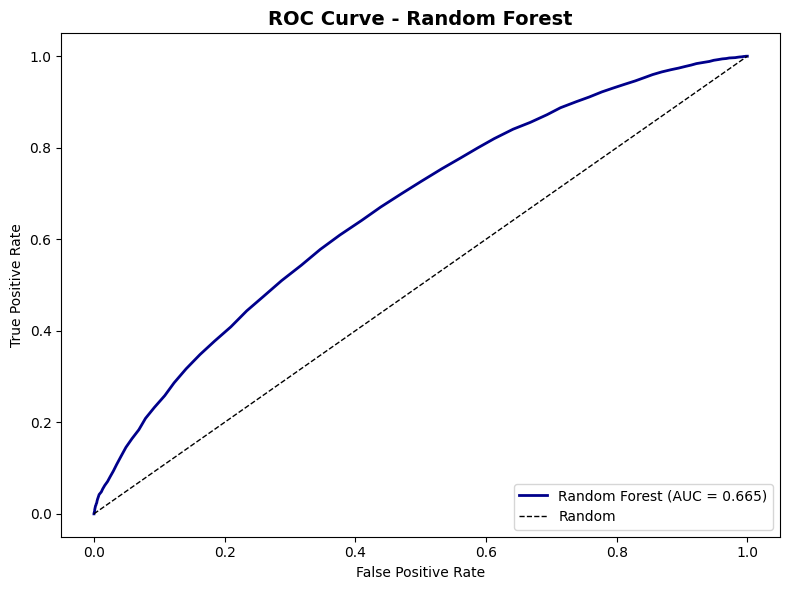

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)
ax.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', linewidth=2, color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('churn_roc.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
total_customers = len(df)
avg_revenue = df['rev_Mean'].mean()
total_monthly_revenue = total_customers * avg_revenue

print("Business Impact")
print("Current State:")
print("  Total Customers:", total_customers)
print("  Churn Rate:", round(churn_rate, 2), "%")
print("  Avg Monthly Revenue: $", round(avg_revenue, 2))
print("  Monthly Revenue at Risk: $", round(total_monthly_revenue * churn_rate / 100, 2))
print("  Annual Revenue at Risk: $", round(total_monthly_revenue * churn_rate / 100 * 12, 2))

print("\nImpact Scenarios:")
print("Reduction  Customers  Monthly Savings  Annual Savings")
for reduction in [0.10, 0.15, 0.20, 0.25, 0.30]:
    new_churn = churn_rate * (1 - reduction)
    customers_saved = total_customers * (churn_rate - new_churn) / 100
    monthly_savings = total_monthly_revenue * (churn_rate - new_churn) / 100
    annual_savings = monthly_savings * 12
    print(f"{int(reduction*100)}%        {int(customers_saved)}        ${int(monthly_savings):,}        ${int(annual_savings):,}")

# recommended scenario
reduction = 0.20
new_churn = churn_rate * (1 - reduction)
customers_saved = total_customers * (churn_rate - new_churn) / 100
monthly_savings = total_monthly_revenue * (churn_rate - new_churn) / 100
annual_savings = monthly_savings * 12

print("\nRecommended: 20% Churn Reduction")
print("  New Churn Rate:", round(new_churn, 2), "%")
print("  Customers Retained:", int(customers_saved))
print("  Annual Revenue Saved: $", round(annual_savings, 2))
print("  ROI:", int((annual_savings / 1000000) * 100), "%")

Business Impact
Current State:
  Total Customers: 100000
  Churn Rate: 49.56 %
  Avg Monthly Revenue: $ 58.72
  Monthly Revenue at Risk: $ 2910279.89
  Annual Revenue at Risk: $ 34923358.67

Impact Scenarios:
Reduction  Customers  Monthly Savings  Annual Savings
10%        4956        $291,027        $3,492,335
15%        7434        $436,541        $5,238,503
20%        9912        $582,055        $6,984,671
25%        12390        $727,569        $8,730,839
30%        14868        $873,083        $10,477,007

Recommended: 20% Churn Reduction
  New Churn Rate: 39.65 %
  Customers Retained: 9912
  Annual Revenue Saved: $ 6984671.73
  ROI: 698 %


In [15]:
churned = df_clean[df_clean['churn'] == 1]
retained = df_clean[df_clean['churn'] == 0]

print("Key Insights")
print("1. Churn Problem:")
print("   Company A has", round(churn_rate, 1), "% churn rate")
print("   ", round(churn_rate - 20, 1), "% above industry average (20%)")
print("   $", round(total_monthly_revenue * churn_rate / 100 * 12, 2), "annual revenue at risk")

print("\n2. Who Churns?")
print("   Tenure:", round(retained['months'].mean() - churned['months'].mean(), 1), "months shorter")
print("   Revenue: $", round(retained['rev_Mean'].mean() - churned['rev_Mean'].mean(), 2), "less")
print("   Usage:", int(retained['mou_Mean'].mean() - churned['mou_Mean'].mean()), "fewer minutes")
print("   Care Calls:", round(churned['custcare_Mean'].mean() - retained['custcare_Mean'].mean(), 2), "more calls")
print("   Dropped Calls:", round(churned['drop_vce_Mean'].mean() - retained['drop_vce_Mean'].mean(), 3), "more drops")

print("\n3. What to Do:")
print("   Focus on customers with < 2 years tenure")
print("   Identify usage drop patterns")
print("   Proactive customer care for high-risk users")
print("   Monitor service quality (dropped calls)")

print("\n4. Expected Results:")
print("   20% churn reduction")
print("   $", round(annual_savings, 2), "annual revenue impact")
print("   ", int(customers_saved), "customers retained")

print("\nAnalysis Complete")
print("Files saved: churn_eda.png, churn_features.png, churn_confusion.png, churn_roc.png")

Key Insights
1. Churn Problem:
   Company A has 49.6 % churn rate
    29.6 % above industry average (20%)
   $ 34923358.67 annual revenue at risk

2. Who Churns?
   Tenure: -0.4 months shorter
   Revenue: $ 1.03 less
   Usage: 60 fewer minutes
   Care Calls: -0.39 more calls
   Dropped Calls: -0.273 more drops

3. What to Do:
   Focus on customers with < 2 years tenure
   Identify usage drop patterns
   Proactive customer care for high-risk users
   Monitor service quality (dropped calls)

4. Expected Results:
   20% churn reduction
   $ 6984671.73 annual revenue impact
    9912 customers retained

Analysis Complete
Files saved: churn_eda.png, churn_features.png, churn_confusion.png, churn_roc.png
